In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [31]:
df_1 = pd.read_parquet('results/thirty-day-ahead/samples/monte_carlo/2024-01-10.parquet')
df_1 = df_1.round(2)
df_1.head()

,DGS1MO_future_val,DGS3MO_future_val,DGS6MO_future_val,DGS1_future_val,DGS2_future_val,DGS3_future_val,DGS5_future_val,DGS7_future_val,DGS10_future_val,DGS20_future_val,DGS30_future_val
0,5.53,5.46,5.23,4.82,4.37,0.04,0.04,4.01,4.04,4.35,4.2
1,5.53,5.46,5.23,4.82,4.37,0.04,0.04,4.01,4.04,4.35,4.2
2,5.53,5.46,5.23,4.82,4.37,0.04,0.04,4.01,4.04,4.35,4.2
3,5.53,5.46,5.23,4.82,4.37,0.04,0.04,4.01,4.04,4.35,4.2
4,5.53,5.46,5.23,4.82,4.37,0.04,0.04,4.01,4.04,4.35,4.2


In [27]:
future_vals = [
    'DGS1MO_future_val', 'DGS3MO_future_val', 'DGS6MO_future_val',
    'DGS1_future_val', 'DGS2_future_val', 'DGS3_future_val', 'DGS5_future_val',
    'DGS7_future_val', 'DGS10_future_val', 'DGS20_future_val', 'DGS30_future_val'
]
df_1_actuals = pd.read_parquet('data/bond_yields_train_shifted_30_sim.parquet')
df_1_actuals.loc[df_1_actuals.index.to_timestamp() == pd.to_datetime('2024-01-10')][future_vals]

,DGS1MO_future_val,DGS3MO_future_val,DGS6MO_future_val,DGS1_future_val,DGS2_future_val,DGS3_future_val,DGS5_future_val,DGS7_future_val,DGS10_future_val,DGS20_future_val,DGS30_future_val
period,,,,,,,,,,,
2024-01-10,5.49,5.44,5.26,4.86,4.48,4.25,4.14,4.17,4.17,4.48,4.37


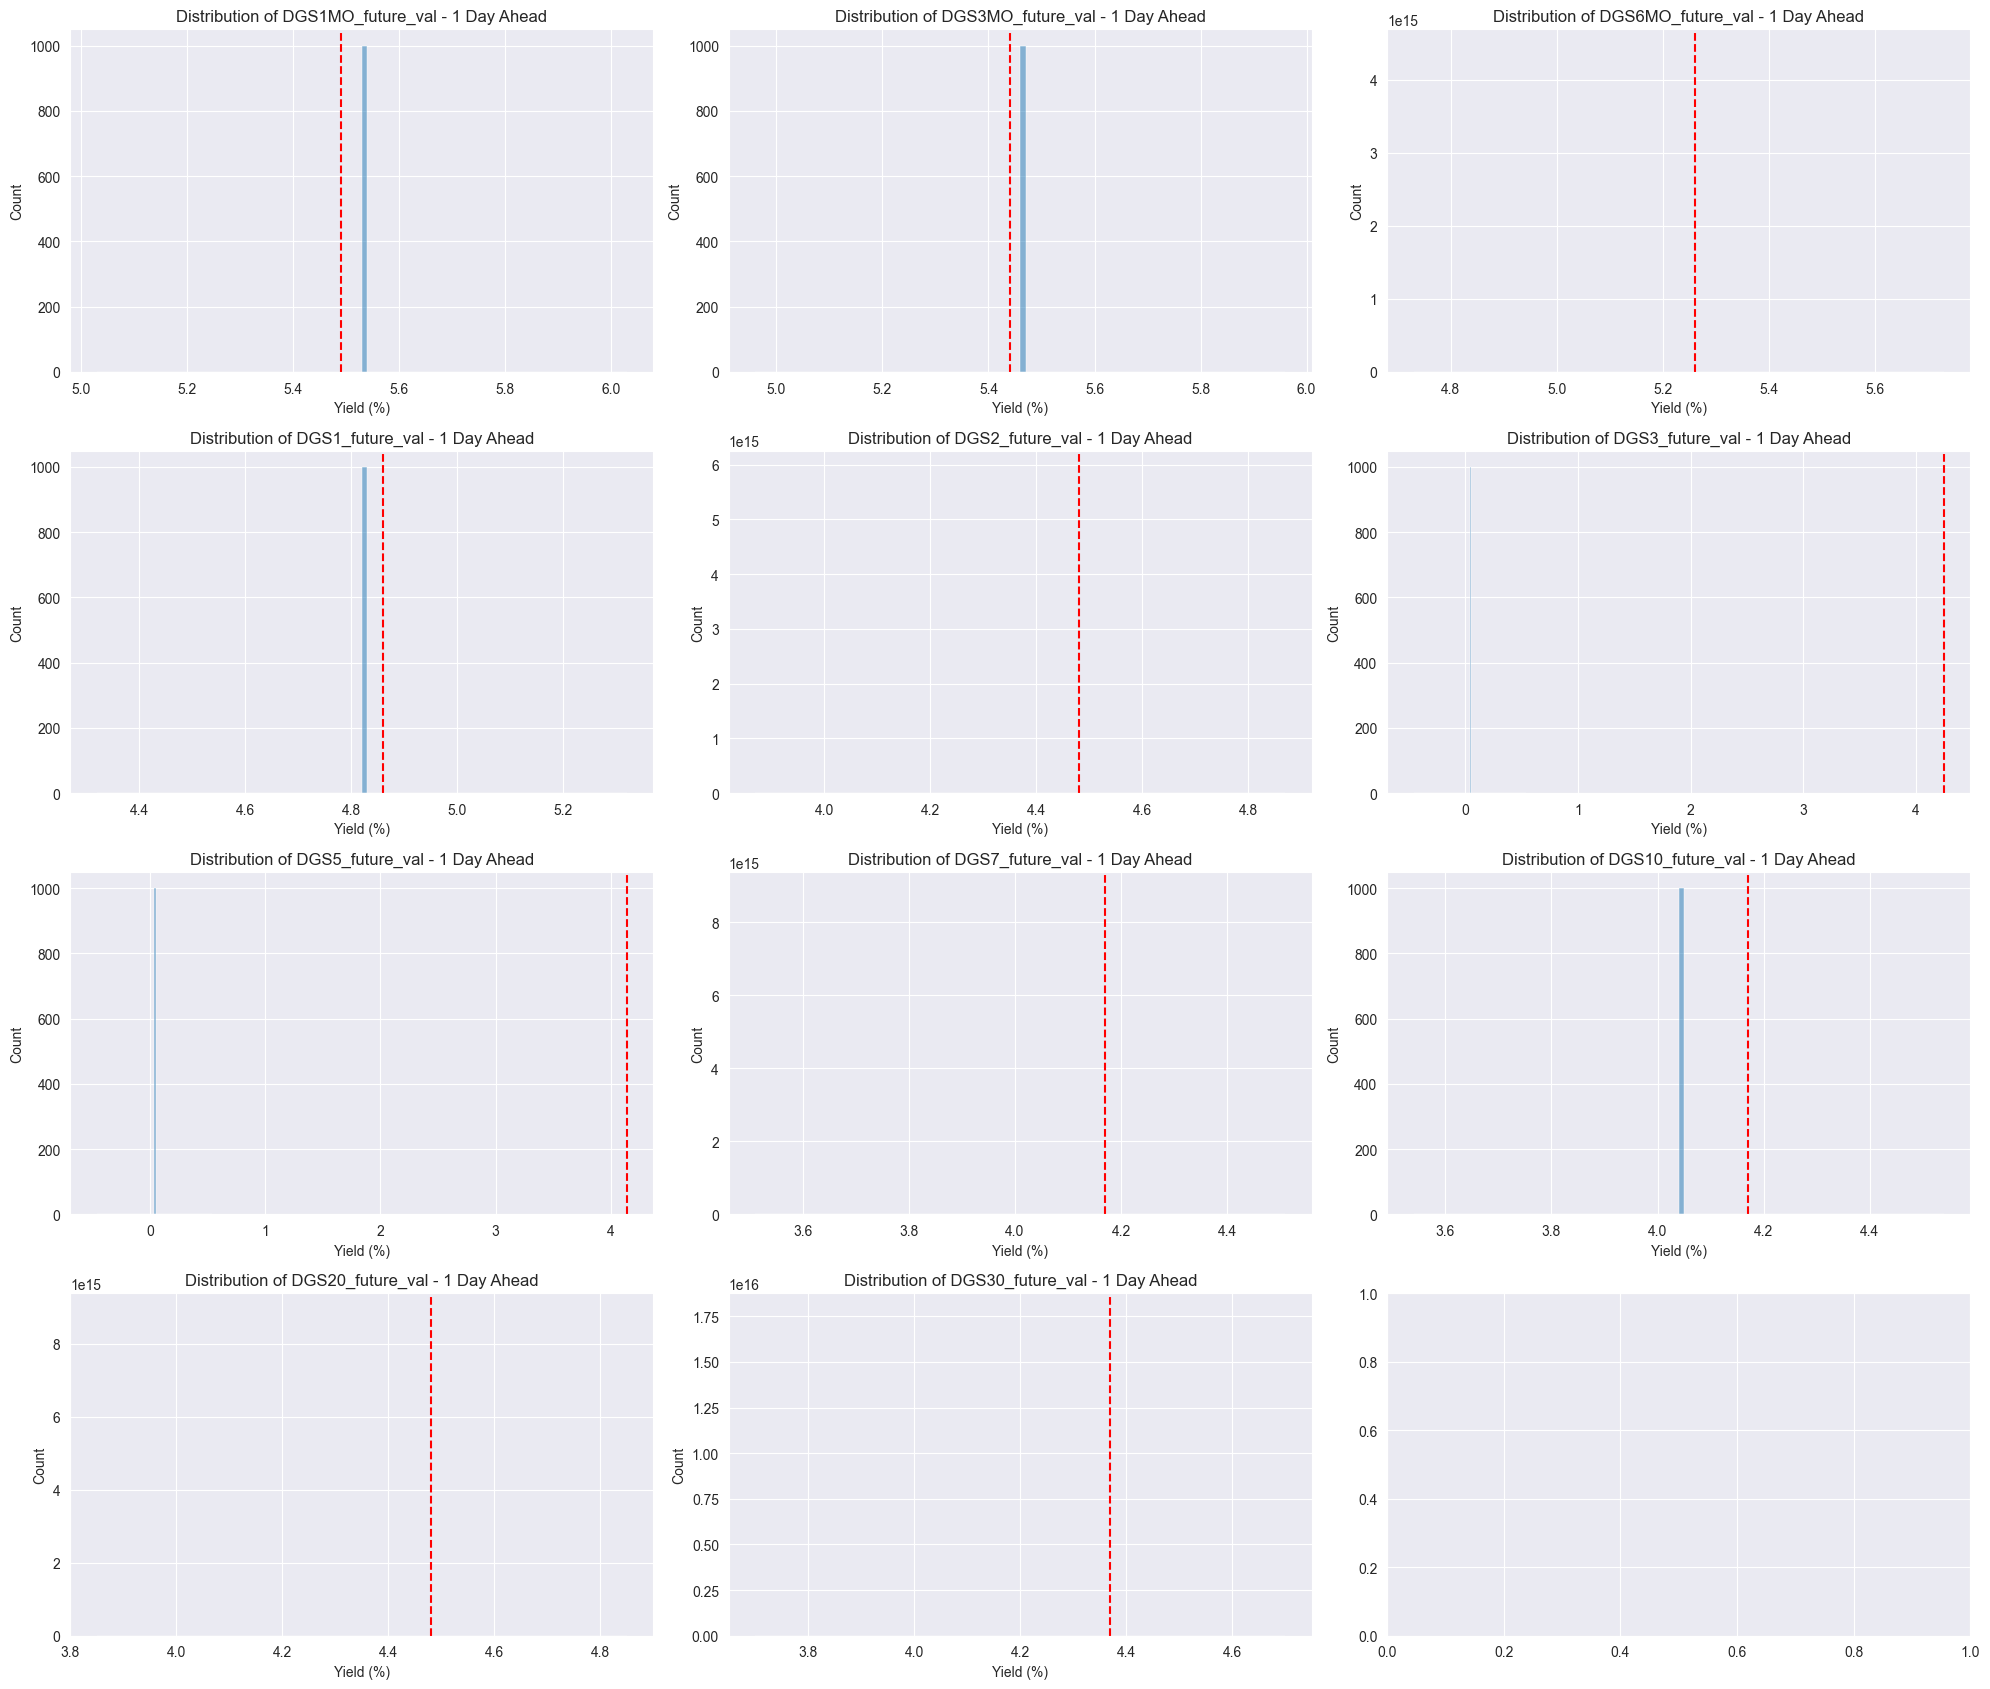

In [37]:
# plot the distribution of each sample column with the actual as a vertical dash line
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(20, 17))
axes = axes.flatten()
for i, col in enumerate(future_vals):
    sns.histplot(df_1[col], ax=axes[i],  bins=100, kde=True)
    axes[i].axvline(df_1_actuals.loc[df_1_actuals.index.to_timestamp() == pd.to_datetime('2024-01-10')][col].values[0], color='red', linestyle='--')
    axes[i].set_title(f'Distribution of {col} - 1 Day Ahead')
    axes[i].set_xlabel('Yield (%)')
plt.tight_layout()
plt.show()

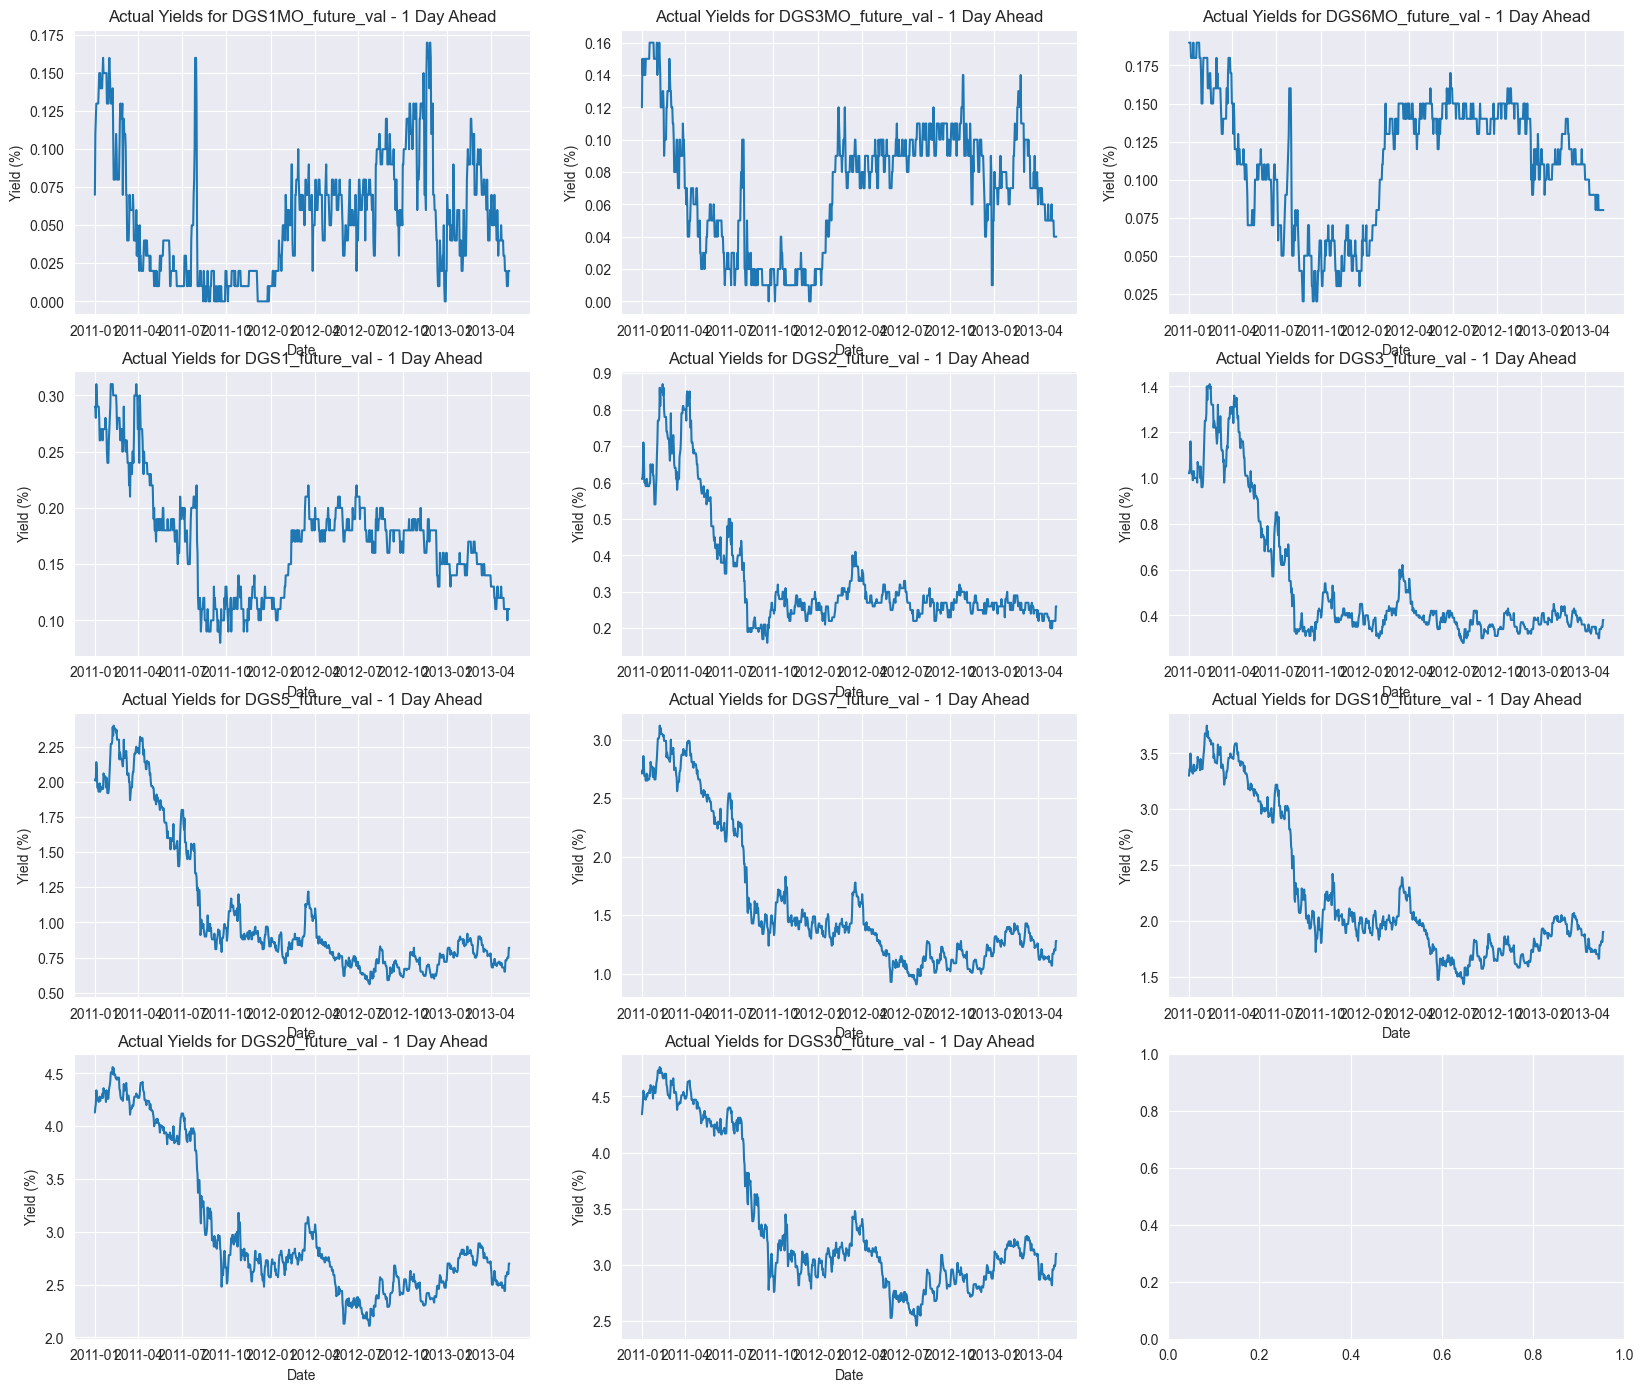

In [11]:
# Display a line plot of the actuals up to 2013-05-10
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(20, 17))
axes = axes.flatten()
df_tmp = df_1_actuals.loc[df_1_actuals.index.to_timestamp() <= pd.to_datetime('2013-05-10')]
x_vals = df_tmp.index.to_timestamp()
for i, col in enumerate(future_vals):

    sns.lineplot(data=df_tmp, x=x_vals, y=col, ax=axes[i])
    axes[i].set_title(f'Actual Yields for {col} - 1 Day Ahead')
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('Yield (%)')

In [42]:
df_1_actuals.iloc[:800][['DGS1MO', 'DGS1MO_future_val', 'DGS1MO_gain_loss_30d']]
# df_1_actuals.iloc[:800]['DGS1MO_gain_loss_30d']

,DGS1MO,DGS1MO_future_val,DGS1MO_gain_loss_30d
period,,,
2011-01-01,0.0007,0.15,0.0008
2011-01-02,0.0007,0.16,0.0009
2011-01-03,0.0011,0.15,0.0004
2011-01-04,0.0012,0.14,0.0002
2011-01-05,0.0013,0.13,0.0000
...,...,...,...
2013-03-06,0.0009,0.05,-0.0004
2013-03-07,0.0010,0.05,-0.0005
2013-03-08,0.0009,0.05,-0.0004
